In [2]:
import json
import os
import numpy as np
import torch
from torch_geometric.datasets import JODIEDataset

from data.jodie import JODIEBinnedDataset, JODIEConfig


def describe_jodie_dataset(root: str, name: str, bin_size: float = 3600.0):
    ds = JODIEBinnedDataset(JODIEConfig(root=root, name=name, bin_size=bin_size))
    raw = JODIEDataset(root=root, name=name)[0]  # access y too if present

    src = ds._src_all
    dst = ds._dst_all
    bins = ds._bin_id_all
    msg = ds._msg_all
    y = getattr(raw, "y", None)
    t = getattr(raw, "t", None)

    num_users = int(src.unique().numel())
    num_items = int(dst.unique().numel())
    num_events = int(src.numel())
    num_unique_pairs = int(torch.unique(torch.stack([src, dst], dim=1), dim=0).size(0))

    bipartite_density = num_unique_pairs / (num_users * num_items)

    bin_counts = torch.bincount(bins, minlength=int(bins.max().item()) + 1)
    active_bin_counts = bin_counts[bin_counts > 0]

    user_deg = torch.bincount(src)
    item_deg = torch.bincount(dst - int(dst.min()))

    repeat_flags = []
    last_item_for_user = {}
    for s, d in zip(src.tolist(), dst.tolist()):
        repeat_flags.append(int(last_item_for_user.get(s, -1) == d))
        last_item_for_user[s] = d
    repeat_rate = float(np.mean(repeat_flags)) if repeat_flags else 0.0

    out = {
        "dataset": name,
        "bin_size": bin_size,
        "num_users": num_users,
        "num_items": num_items,
        "num_nodes_merged_space": ds.spec().num_nodes,
        "num_events": num_events,
        "num_bins": int(ds.spec().num_bins),
        "feature_dim": 0 if msg is None else int(msg.size(-1)),
        "num_unique_pairs": num_unique_pairs,
        "bipartite_density": bipartite_density,
        "events_per_active_bin_mean": float(active_bin_counts.float().mean().item()),
        "events_per_active_bin_std": float(active_bin_counts.float().std().item()),
        "empty_bin_fraction": float((bin_counts == 0).float().mean().item()),
        "user_events_mean": float(user_deg[user_deg > 0].float().mean().item()),
        "user_events_median": float(user_deg[user_deg > 0].float().median().item()),
        "user_events_max": int(user_deg.max().item()),
        "item_events_mean": float(item_deg[item_deg > 0].float().mean().item()),
        "item_events_median": float(item_deg[item_deg > 0].float().median().item()),
        "item_events_max": int(item_deg.max().item()),
        "consecutive_repeat_rate": repeat_rate,
    }

    if t is not None:
        out["raw_time_span"] = float(t.max().item() - t.min().item())

    if y is not None:
        y = y.to(torch.float32)
        out["positive_label_rate"] = float(y.mean().item())
        out["num_positive_labels"] = int(y.sum().item())

    return out


def main():
    # print(json.dumps(describe_jodie_dataset("./data/JODIE", "MOOC"), indent=2))
    root = "./data/JODIE"
    datasets = ["Wikipedia", "Reddit", "MOOC", "LastFM"]
    os.makedirs("results", exist_ok=True)

    profiles = {}
    for name in datasets:
        print(f"Profiling {name}...")
        profiles[name] = describe_jodie_dataset(root=root, name=name, bin_size=3600.0)
        print(json.dumps(profiles[name], indent=2))
        print()

    with open("results/jodie_dataset_profiles.json", "w") as f:
        json.dump(profiles, f, indent=2)

    print("Saved to results/jodie_dataset_profiles.json")


if __name__ == "__main__":
    main()

Profiling Wikipedia...
{
  "dataset": "Wikipedia",
  "bin_size": 3600.0,
  "num_users": 8227,
  "num_items": 1000,
  "num_nodes_merged_space": 9227,
  "num_events": 157474,
  "num_bins": 744,
  "feature_dim": 172,
  "num_unique_pairs": 18257,
  "bipartite_density": 0.0022191564361249546,
  "events_per_active_bin_mean": 211.65859985351562,
  "events_per_active_bin_std": 56.27574920654297,
  "empty_bin_fraction": 0.0,
  "user_events_mean": 19.14112091064453,
  "user_events_median": 2.0,
  "user_events_max": 1603,
  "item_events_mean": 157.4739990234375,
  "item_events_median": 119.0,
  "item_events_max": 1937,
  "consecutive_repeat_rate": 0.7913242821037123,
  "raw_time_span": 2678373.0,
  "positive_label_rate": 0.0013780052540823817,
  "num_positive_labels": 217
}

Profiling Reddit...
{
  "dataset": "Reddit",
  "bin_size": 3600.0,
  "num_users": 10000,
  "num_items": 984,
  "num_nodes_merged_space": 10984,
  "num_events": 672447,
  "num_bins": 744,
  "feature_dim": 172,
  "num_unique_pa

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

with open("results/jodie_dataset_profiles.json", "r") as f:
    profiles = json.load(f)

In [4]:
df = pd.DataFrame.from_dict(profiles, orient="index").reset_index(drop=True)

# keep a stable dataset order
order = ["Wikipedia", "Reddit", "MOOC", "LastFM"]
df["dataset"] = pd.Categorical(df["dataset"], categories=order, ordered=True)
df = df.sort_values("dataset").reset_index(drop=True)

# derived metrics
df["unique_pair_event_ratio"] = df["num_unique_pairs"] / df["num_events"]
df["user_skew_ratio"] = df["user_events_max"] / df["user_events_median"]
df["item_skew_ratio"] = df["item_events_max"] / df["item_events_median"]

df

,dataset,bin_size,num_users,num_items,num_nodes_merged_space,num_events,num_bins,feature_dim,num_unique_pairs,bipartite_density,...,item_events_mean,item_events_median,item_events_max,consecutive_repeat_rate,raw_time_span,positive_label_rate,num_positive_labels,unique_pair_event_ratio,user_skew_ratio,item_skew_ratio
0,Wikipedia,3600.0,8227,1000,9227,157474,744,172,18257,0.002219,...,157.473999,119.0,1937,0.791324,2678373.0,0.001378,217,0.115937,801.500000,16.277311
1,Reddit,3600.0,10000,984,10984,672447,744,172,78516,0.007979,...,683.381104,134.0,58727,0.614230,2678390.0,0.000544,366,0.116762,106.590909,438.261194
2,MOOC,3600.0,7047,97,7144,411749,715,4,178443,0.261050,...,4244.834961,2954.0,19474,0.182636,2572086.0,0.009875,4066,0.433378,13.289474,6.592417
3,LastFM,3600.0,980,1000,1980,1293103,38086,2,154993,0.158156,...,1293.103027,1113.0,3992,0.098279,137107267.0,0.000000,0,0.119861,98.791985,3.586703


In [5]:
summary_cols = [
    "dataset",
    "num_events",
    "num_users",
    "num_items",
    "num_bins",
    "bipartite_density",
    "consecutive_repeat_rate",
    "events_per_active_bin_mean",
    "events_per_active_bin_std",
    "positive_label_rate",
    "user_skew_ratio",
    "item_skew_ratio",
]

display(df[summary_cols].round(4))

,dataset,num_events,num_users,num_items,num_bins,bipartite_density,consecutive_repeat_rate,events_per_active_bin_mean,events_per_active_bin_std,positive_label_rate,user_skew_ratio,item_skew_ratio
0,Wikipedia,157474,8227,1000,744,0.0022,0.7913,211.6586,56.2757,0.0014,801.5000,16.2773
1,Reddit,672447,10000,984,744,0.0080,0.6142,903.8266,207.4005,0.0005,106.5909,438.2612
2,MOOC,411749,7047,97,715,0.2610,0.1826,583.2139,492.6122,0.0099,13.2895,6.5924
3,LastFM,1293103,980,1000,38086,0.1582,0.0983,34.4451,22.4157,0.0000,98.7920,3.5867


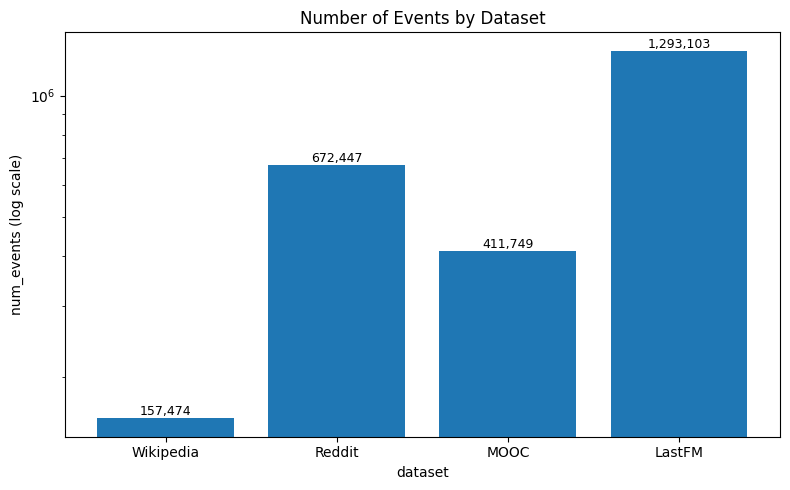

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(df["dataset"], df["num_events"])
plt.yscale("log")
plt.title("Number of Events by Dataset")
plt.ylabel("num_events (log scale)")
plt.xlabel("dataset")

for x, y in zip(df["dataset"], df["num_events"]):
    plt.text(x, y, f"{int(y):,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

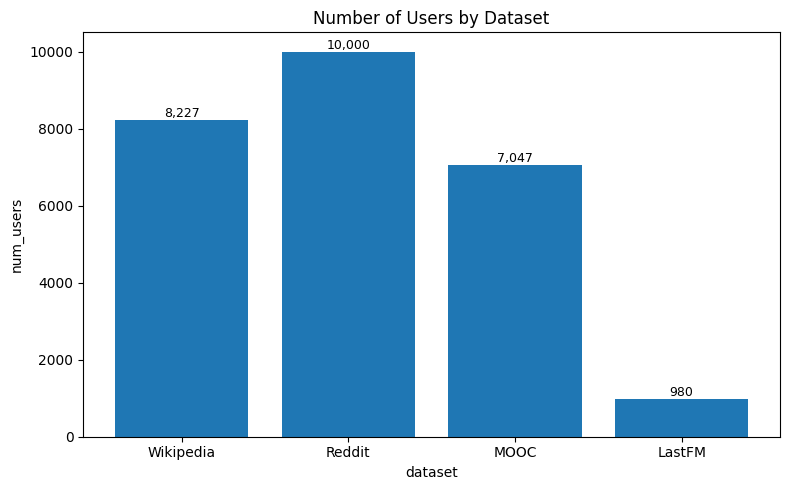

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(df["dataset"], df["num_users"])
plt.title("Number of Users by Dataset")
plt.ylabel("num_users")
plt.xlabel("dataset")

for x, y in zip(df["dataset"], df["num_users"]):
    plt.text(x, y, f"{int(y):,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

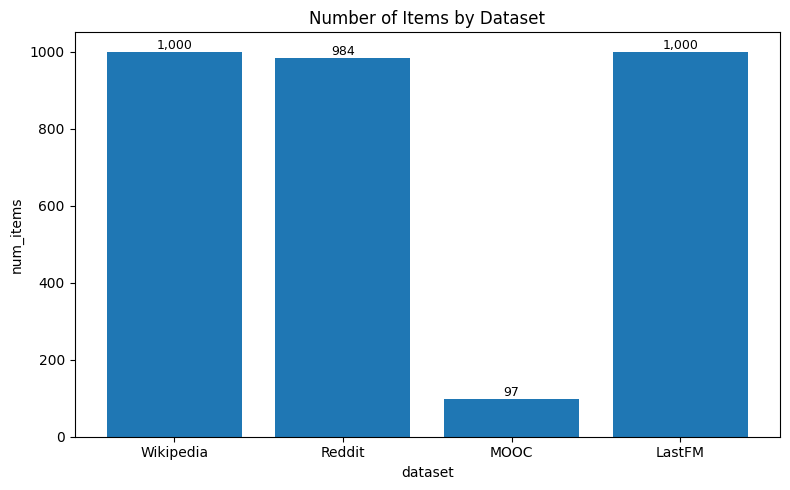

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(df["dataset"], df["num_items"])
plt.title("Number of Items by Dataset")
plt.ylabel("num_items")
plt.xlabel("dataset")

for x, y in zip(df["dataset"], df["num_items"]):
    plt.text(x, y, f"{int(y):,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

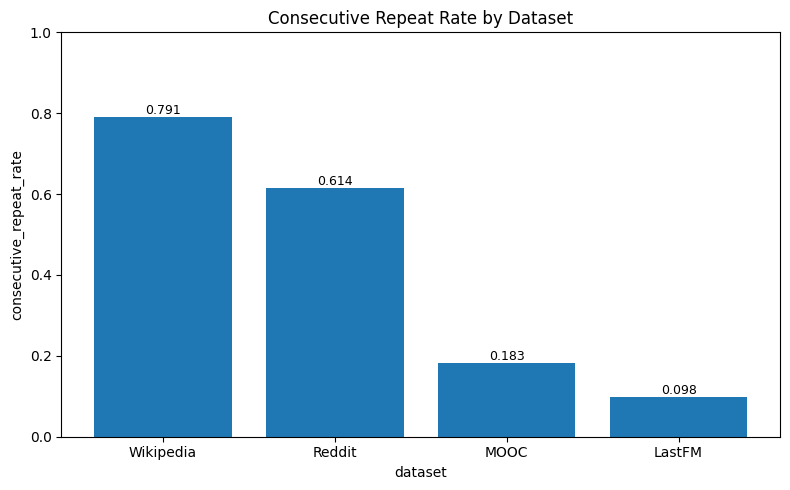

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(df["dataset"], df["consecutive_repeat_rate"])
plt.title("Consecutive Repeat Rate by Dataset")
plt.ylabel("consecutive_repeat_rate")
plt.xlabel("dataset")
plt.ylim(0, 1)

for x, y in zip(df["dataset"], df["consecutive_repeat_rate"]):
    plt.text(x, y, f"{y:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

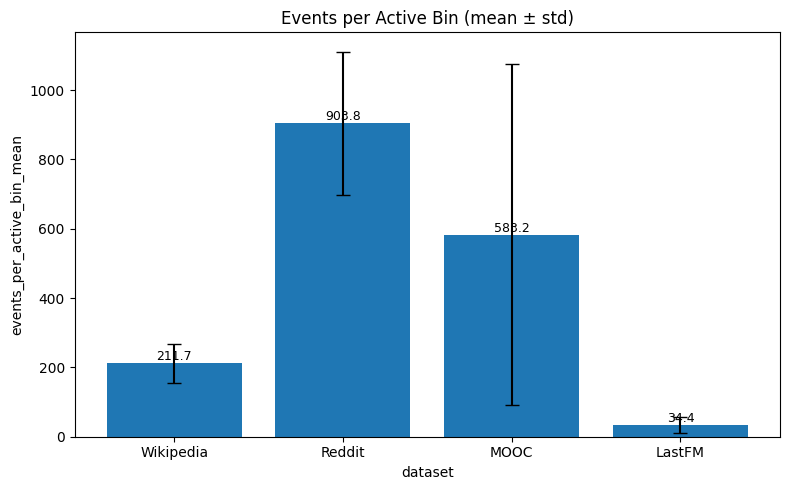

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(
    df["dataset"],
    df["events_per_active_bin_mean"],
    yerr=df["events_per_active_bin_std"],
    capsize=5
)
plt.title("Events per Active Bin (mean ± std)")
plt.ylabel("events_per_active_bin_mean")
plt.xlabel("dataset")

for x, y in zip(df["dataset"], df["events_per_active_bin_mean"]):
    plt.text(x, y, f"{y:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

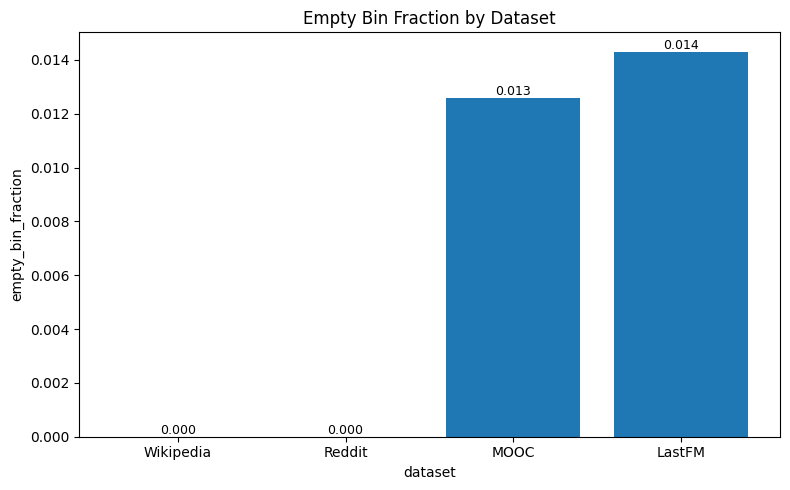

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(df["dataset"], df["empty_bin_fraction"])
plt.title("Empty Bin Fraction by Dataset")
plt.ylabel("empty_bin_fraction")
plt.xlabel("dataset")

for x, y in zip(df["dataset"], df["empty_bin_fraction"]):
    plt.text(x, y, f"{y:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

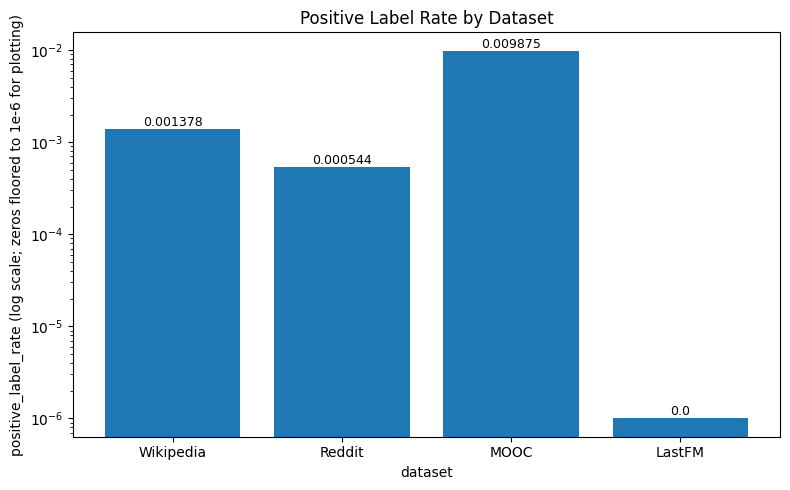

In [12]:
plot_rates = df["positive_label_rate"].replace(0, 1e-6)

plt.figure(figsize=(8, 5))
plt.bar(df["dataset"], plot_rates)
plt.yscale("log")
plt.title("Positive Label Rate by Dataset")
plt.ylabel("positive_label_rate (log scale; zeros floored to 1e-6 for plotting)")
plt.xlabel("dataset")

for x, true_y, plot_y in zip(df["dataset"], df["positive_label_rate"], plot_rates):
    label = f"{true_y:.6f}" if true_y > 0 else "0.0"
    plt.text(x, plot_y, label, ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

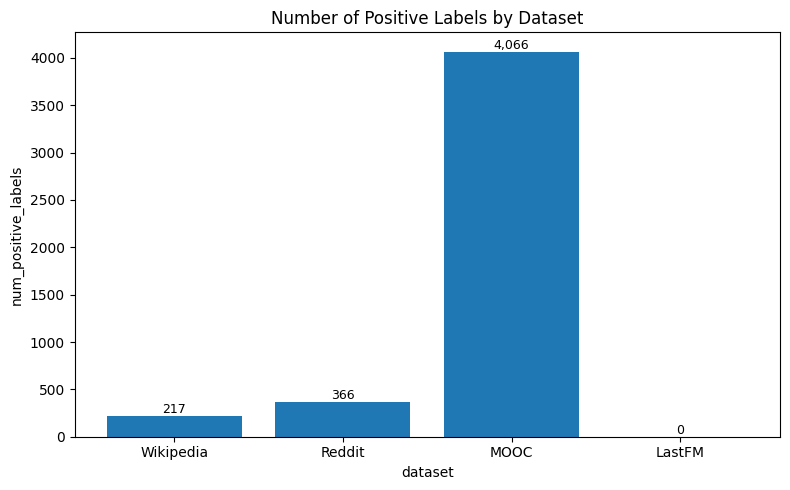

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(df["dataset"], df["num_positive_labels"])
plt.title("Number of Positive Labels by Dataset")
plt.ylabel("num_positive_labels")
plt.xlabel("dataset")

for x, y in zip(df["dataset"], df["num_positive_labels"]):
    plt.text(x, y, f"{int(y):,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

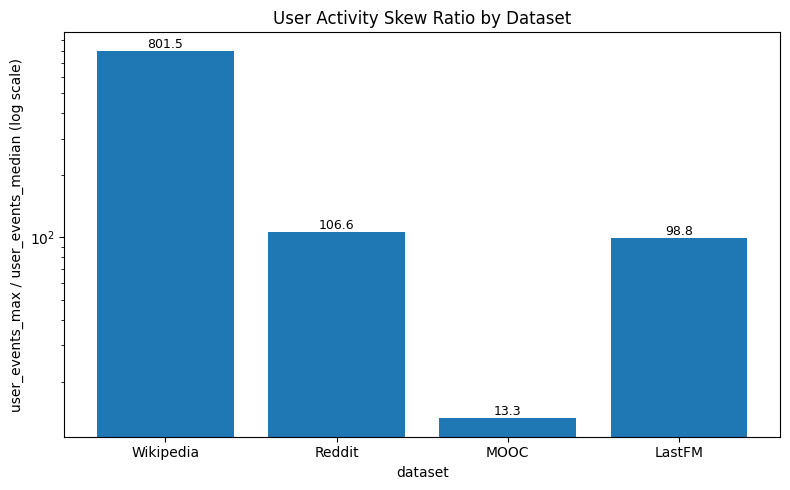

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(df["dataset"], df["user_skew_ratio"])
plt.yscale("log")
plt.title("User Activity Skew Ratio by Dataset")
plt.ylabel("user_events_max / user_events_median (log scale)")
plt.xlabel("dataset")

for x, y in zip(df["dataset"], df["user_skew_ratio"]):
    plt.text(x, y, f"{y:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

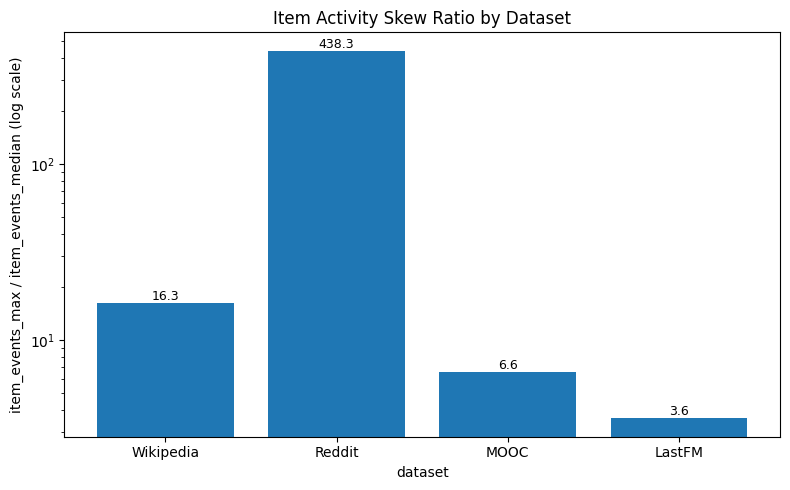

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(df["dataset"], df["item_skew_ratio"])
plt.yscale("log")
plt.title("Item Activity Skew Ratio by Dataset")
plt.ylabel("item_events_max / item_events_median (log scale)")
plt.xlabel("dataset")

for x, y in zip(df["dataset"], df["item_skew_ratio"]):
    plt.text(x, y, f"{y:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

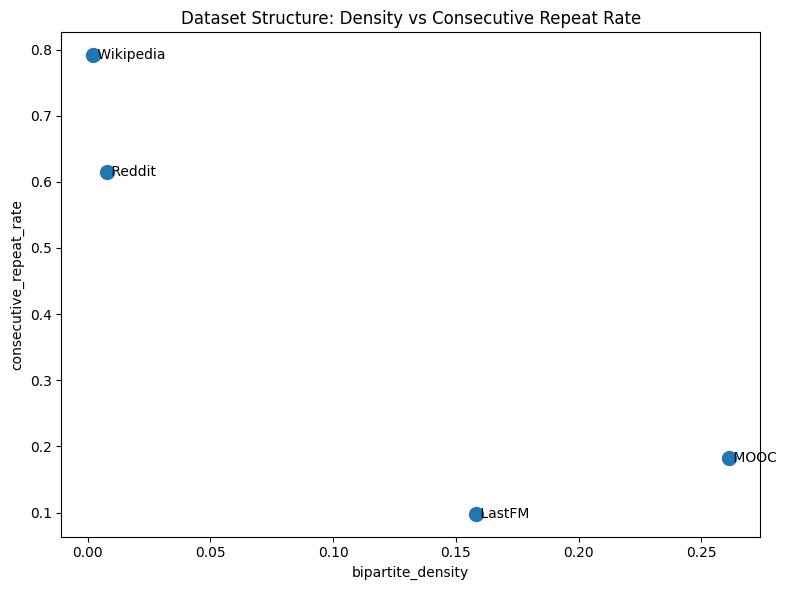

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(df["bipartite_density"], df["consecutive_repeat_rate"], s=100)

for _, row in df.iterrows():
    plt.text(
        row["bipartite_density"],
        row["consecutive_repeat_rate"],
        " " + row["dataset"],
        va="center"
    )

plt.title("Dataset Structure: Density vs Consecutive Repeat Rate")
plt.xlabel("bipartite_density")
plt.ylabel("consecutive_repeat_rate")
plt.tight_layout()
plt.show()

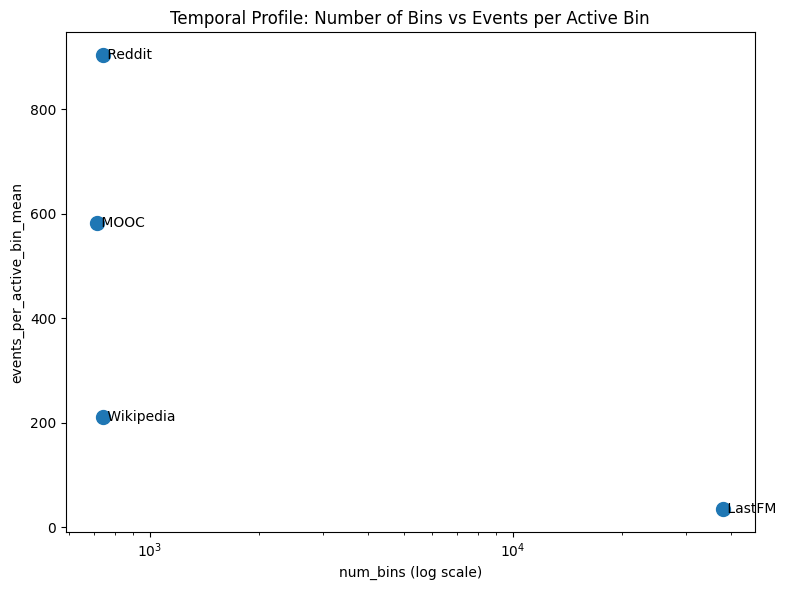

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(df["num_bins"], df["events_per_active_bin_mean"], s=100)

for _, row in df.iterrows():
    plt.text(
        row["num_bins"],
        row["events_per_active_bin_mean"],
        " " + row["dataset"],
        va="center"
    )

plt.xscale("log")
plt.title("Temporal Profile: Number of Bins vs Events per Active Bin")
plt.xlabel("num_bins (log scale)")
plt.ylabel("events_per_active_bin_mean")
plt.tight_layout()
plt.show()

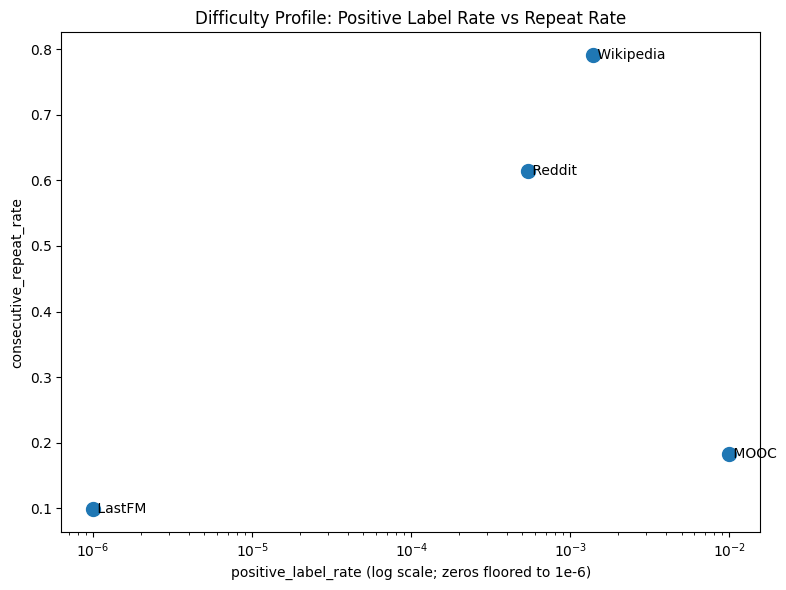

In [18]:
plot_rates = df["positive_label_rate"].replace(0, 1e-6)

plt.figure(figsize=(8, 6))
plt.scatter(plot_rates, df["consecutive_repeat_rate"], s=100)

for i, row in df.iterrows():
    x = 1e-6 if row["positive_label_rate"] == 0 else row["positive_label_rate"]
    plt.text(x, row["consecutive_repeat_rate"], " " + row["dataset"], va="center")

plt.xscale("log")
plt.title("Difficulty Profile: Positive Label Rate vs Repeat Rate")
plt.xlabel("positive_label_rate (log scale; zeros floored to 1e-6)")
plt.ylabel("consecutive_repeat_rate")
plt.tight_layout()
plt.show()

In [19]:
df.to_csv("results/jodie_dataset_profiles_table.csv", index=False)
df.to_json("results/jodie_dataset_profiles_table.json", orient="records", indent=2)

print("Saved:")
print("  results/jodie_dataset_profiles_table.csv")
print("  results/jodie_dataset_profiles_table.json")

Saved:
  results/jodie_dataset_profiles_table.csv
  results/jodie_dataset_profiles_table.json
